In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from IPython.display import HTML, display

import matplotlib.pyplot as plt
import seaborn as sns

random_state = 42

# Week 10: Clustering - K-Means

In [2]:
cancer_deaths = pd.read_csv(r'..\Processed Data\cdc_cancer_deaths_encoded.csv')
cancer_deaths.head()

,AGE,CAUSE_RECODE_113,DATA_YEAR,EDUCATION_CODED,HISPANIC_CODED,MANNER_OF_DEATH_CODED,MONTH_OF_DEATH,PLACE_OF_DEATH_CODED,RESIDENT_STATUS_CODED,WEEKDAY_OF_DEATH,...,PLACE_OF_DEATH_Hospital (Dead on Arrival),PLACE_OF_DEATH_Hospital (Inpatient),PLACE_OF_DEATH_Hospital (Outpatient/ER),PLACE_OF_DEATH_Nursing home,PLACE_OF_DEATH_Other,PLACE_OF_DEATH_Unknown,AUTOPSY_N,AUTOPSY_U,AUTOPSY_Y,AUTOPSY_n
0,93.0,33,2018,61,6,7.0,1,6,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,61.0,23,2018,51,6,7.0,1,4,1,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,63.0,25,2018,41,6,7.0,1,4,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,67.0,27,2018,31,6,7.0,1,4,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,76.0,27,2018,31,6,7.0,1,4,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [3]:
# Preprocessing: removing redundant features since this dataset is one-hot encoded
cancer_deaths = cancer_deaths.drop(columns=['CAUSE_RECODE_113', 'EDUCATION_CODED', 'HISPANIC_CODED', 'MANNER_OF_DEATH_CODED', 'PLACE_OF_DEATH_CODED', 'RESIDENT_STATUS_CODED', 'SEX_CODED_F', 'SEX_Male'])
cancer_deaths.head()

,AGE,DATA_YEAR,MONTH_OF_DEATH,WEEKDAY_OF_DEATH,SEX_Female,RACE_AIAN,RACE_Asian,RACE_Black,RACE_Hispanic,RACE_Multiracial,...,PLACE_OF_DEATH_Hospital (Dead on Arrival),PLACE_OF_DEATH_Hospital (Inpatient),PLACE_OF_DEATH_Hospital (Outpatient/ER),PLACE_OF_DEATH_Nursing home,PLACE_OF_DEATH_Other,PLACE_OF_DEATH_Unknown,AUTOPSY_N,AUTOPSY_U,AUTOPSY_Y,AUTOPSY_n
0,93.0,2018,1,3,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,61.0,2018,1,4,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,63.0,2018,1,5,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,67.0,2018,1,6,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,76.0,2018,1,2,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Scaling, Engineering Features, and Dimensionality Reduction Before K-Means

In [6]:
df = cancer_deaths.copy()

# Preserving original years for cluster table later
years_original = df['DATA_YEAR'].copy()

# Cyclical encoding for MONTH and WEEKDAY
df['MONTH_SIN'] = np.sin(2 * np.pi * df['MONTH_OF_DEATH'] / 12)
df['MONTH_COS'] = np.cos(2 * np.pi * df['MONTH_OF_DEATH'] / 12)
df['WEEKDAY_SIN'] = np.sin(2 * np.pi * df['WEEKDAY_OF_DEATH'] / 7)
df['WEEKDAY_COS'] = np.cos(2 * np.pi * df['WEEKDAY_OF_DEATH'] / 7)

# Drop original cols
df = df.drop(columns=['MONTH_OF_DEATH', 'WEEKDAY_OF_DEATH', 'DATA_YEAR'])

# Scale continuous AGE target
scaler = StandardScaler()
df[['AGE']] = scaler.fit_transform(df[['AGE']])

# PCA to reduce dimensionality (originally 100+ features)
pca = PCA(n_components=0.85) # retaining 85% of variance
X_reduced = pca.fit_transform(df)

# K-Means
kmeans = KMeans(n_clusters=5, random_state=random_state)
clusters = kmeans.fit_predict(X_reduced)

cluster_year_counts = pd.crosstab(clusters, years_original, normalize='columns') * 100
print(cluster_year_counts)


DATA_YEAR       2018       2019       2020
row_0                                     
0          17.646355  17.963488  18.123969
1          21.362587  21.404154  22.038697
2          18.517878  18.508873  18.102510
3          16.377457  15.840535  15.216264
4          26.095723  26.282950  26.518560


[Medium: Cyclical Encoding for Time Features](https://medium.com/@indradeep.chatterjee/cyclic-encoding-in-machine-learning-a-practical-guide-with-code-and-intuition-049846419ccb)

## Analyzing K-Means Centroids

In [8]:
df_analysis = cancer_deaths.copy()
df_analysis['CLUSTER'] = clusters

# separate continuous vs binary features
continuous_col = ['AGE']
metadata_cols = ['CLUSTER', 'DATA_YEAR', 'MONTH_OF_DEATH', 'WEEKDAY_OF_DEATH']
binary_cols = [c for c in df_analysis.columns if c not in continuous_col + metadata_cols]

# Group profiles
print("=== AVERAGE AGE BY CLUSTER ===")
display(df_analysis.groupby('CLUSTER')[['AGE']].mean())

# Full population baseline
overall_means = df_analysis[binary_cols].mean()


n_characteristics = 10      # top n features for cluster
n_largest_shifts = 5        # top n features with the largest shifts from the population mean

# display cluster characteristics and shifts
for i in range(5):
    cluster_df = df_analysis[df_analysis['CLUSTER'] == i]
    cluster_means = cluster_df[binary_cols].mean()

    # top prevalance
    top_prev = (
        (cluster_means.sort_values(ascending=False).head(n_characteristics) * 100)
        .round(2)
        .to_frame(name="Prevalance (%)")
    )

    # Top Unique Shifts vs Overall Population
    diff = (cluster_means - overall_means) * 100
    top_diff_idx = diff.abs().sort_values(ascending=False).head(n_largest_shifts).index
    top_unique = diff.loc[top_diff_idx].to_frame(name='Shift vs Baseline (%)')

    # Render Output
    display(HTML(f"<h3>Cluster {i} Summary</h3>"))

    # Display side-by-side or stacked styled DataFrames with visual gradient bars
    display(
        top_prev.style.background_gradient(cmap="Greens").format("{:.2f}%")
    )
    display(
        top_unique.style.background_gradient(cmap="coolwarm", vmin=50, vmax=50).format("{:+.2f}%")
    )
    display(HTML("<hr>")) # Visual separator

=== AVERAGE AGE BY CLUSTER ===


,AGE
CLUSTER,
0,70.412099
1,73.185099
2,85.650585
3,51.835810
4,73.601237


,Prevalance (%)
AUTOPSY_N,95.00%
RESIDENT_STATUS_Resident,84.99%
RACE_Black,59.72%
ETHNIC_GROUP_Non-Hispanic Black,59.72%
MARITAL_STATUS_Married,45.76%
SEX_Female,45.65%
PLACE_OF_DEATH_Home,42.93%
EDUCATION_HS Grad / GED,37.64%
PLACE_OF_DEATH_Hospital (Inpatient),29.47%
RACE_Hispanic,26.94%


,Shift vs Baseline (%)
RACE_White,-76.98%
ETHNIC_GROUP_Non-Hispanic White,-76.98%
ETHNIC_GROUP_Non-Hispanic Black,+47.86%
RACE_Black,+47.86%
RACE_Hispanic,+19.81%


,Prevalance (%)
RACE_White,99.42%
ETHNIC_GROUP_Non-Hispanic White,99.42%
AUTOPSY_N,96.12%
RESIDENT_STATUS_Resident,83.01%
MARITAL_STATUS_Married,66.28%
PLACE_OF_DEATH_Home,49.87%
EDUCATION_HS Grad / GED,40.60%
SEX_Female,37.74%
"CAUSE_OF_DEATH_Malignant neoplasms of trachea, bronchus and lung (C33-C34)",30.44%
EDUCATION_Some College,22.80%


...

,Shift vs Baseline (%)
MARITAL_STATUS_Widowed,+67.01%
MARITAL_STATUS_Married,-46.27%
SEX_Female,+23.59%
ETHNIC_GROUP_Non-Hispanic White,+13.66%
RACE_White,+13.66%


,Prevalance (%)
AUTOPSY_N,95.16%
RACE_White,80.37%
ETHNIC_GROUP_Non-Hispanic White,80.37%
RESIDENT_STATUS_Resident,74.80%
SEX_Female,53.30%
MARITAL_STATUS_Married,46.69%
EDUCATION_HS Grad / GED,40.54%
PLACE_OF_DEATH_Home,38.87%
PLACE_OF_DEATH_Hospital (Inpatient),33.59%
MARITAL_STATUS_Divorced,24.16%


,Shift vs Baseline (%)
MARITAL_STATUS_Widowed,-18.78%
MARITAL_STATUS_Never Married,+14.07%
PLACE_OF_DEATH_Hospital (Inpatient),+10.65%
RESIDENT_STATUS_Resident,-8.00%
PLACE_OF_DEATH_Home,-7.37%


,Prevalance (%)
RACE_White,99.38%
ETHNIC_GROUP_Non-Hispanic White,99.38%
AUTOPSY_N,96.17%
RESIDENT_STATUS_Resident,83.82%
MARITAL_STATUS_Married,69.00%
PLACE_OF_DEATH_Home,51.33%
EDUCATION_HS Grad / GED,40.14%
SEX_Female,36.11%
"CAUSE_OF_DEATH_Malignant neoplasms of trachea, bronchus and lung (C33-C34)",30.44%
EDUCATION_Some College,23.01%


,Shift vs Baseline (%)
RACE_White,+22.41%
ETHNIC_GROUP_Non-Hispanic White,+22.41%
MARITAL_STATUS_Married,+20.56%
MARITAL_STATUS_Widowed,-17.98%
ETHNIC_GROUP_Non-Hispanic Black,-11.86%


[AI Acknowlegement: Used Google Gemini to restructure my code for better visualization of the findings](https://share.gemini.google/YLMlpT1eCl8K)

## Cluster Summary:

#### Cluster 0: Racial Minority Population
- **Average Age:** 70.41
- **Core Profile: More diverse than other clusters**
  - 59.72% Black / Non-Hispanic Black
  - 26.94% Hispanic
- **Other Key Characteristics:**
  - 45.76% Married
  - 45.65% Female
  - 42.93% Died at Home
  - 29.47% Died in Hospital (Inpatient)
- **Defining Shifts vs. Baseline:**
  - +47.86% Black / Non-Hispanic Black 
  - +19.81% Hispanic
- **Main Takeaway:** Cluster represents potential racial/ethnic disparities in cancer life expectancy outcomes because this cluster was majority Black and Hispanic with lower average age of death compared to White clusters (roughly 3 years for clusters 1 & 4, and 15 years for cluster 2). This cluster faces higher inpatient deaths compared to White clusters 1 and 4.

#### Cluster 1: Older Married White Male Population
- **Average Age:** 73.18
- **Core Profile: Almost exclusively White, predominantly male, married population with high rates of lung cancer**
  - 99.42% White / Non-Hispanic White
- **Other Key Characteristics:**
  - 66.28% Married
  - 37.74% Female
  - 49.87% Died at Home
  - 30.44% Died from malignant neoplasms of trachea, bronchus and lung
- **Defining Shifts vs. Baseline:**
  - +22.45% White / Non-Hispanic White
  - +17.84% Married
  - -16.16% Widowed
  - -11.86% Non-Hispanic Black
-**Main Takeaway:** Cluster represents White married males having significantly higher lung cancer rates, but die at home. This represents a group with more spousal caregiving capacity enabling home hospice/end-of-life care preference.

#### Cluster 2: Older Widowed Female Population
- **Average Age:** 85.65
- **Core Profile: Elderly, predominantly White widowed women with high utilization of nursing home end-of-life care**
  - 90.63% White / Non-Hispanic White
- **Other Key Characteristics:**
  - 90.29% Widowed
  - 70.87% Female
  - 44.26% Died at Home
  - 22.58% Died in Nursing Home
  - 25.40% Died from malignant neoplasms of trachea, bronchus and lung
- **Defining Shifts vs. Baseline:**
  - +67.01% Widowed
  - -46.27% Married
  - +23.59% Female
  - +13.66% White / Non-Hispanic White
- **Main Takeaway:** Cluster represents predominantly White widowed women dying significantly later than other clusters. They die at home and nursing homes significantly more. This potentially represents women living alone with reduced household caregiving infrastructure leading to higher reliance on institutional settings such as nursing homes. They also die significantly higher from lung cancers than most clusters.

#### Cluster 3: Premature / Younger, Single Population
- **Average Age:** 51.83
- **Core Profile: Middle-aged population with higher rates of divorced status and higher hospital deaths**
  - 80.37% White / Non-Hispanic White
- **Other Key Characteristics:**
  - 46.69% Married
  - 24.16% Divorced
  - 53.30% Female
  - 38.87% Died at Home
  - 33.59% Died in Hospital (Inpatient)
- **Defining Shifts vs. Baseline:**
  - -18.78% Widowed
  - +14.07% Never Married
  - +10.65% Died in Hospital (Inpatient)
  - -7.37% Died at Home
- **Main Takeaway:** Cluster represents a more diverse, middle-age male population who are single (divorced, never married) dying substantially earlier than all other clusters. They die significantly more at home or hospitals. This could allude to the fact they have reduced household caregiving infrastructure leading to higher reliance on institutional settings such as the hospital. It could also mean that this group faces later stage cancers, often more aggressive.

#### Cluster 4: More Educated, Older, Married White Male Population
- **Average Age:** 73.60
- **Core Profile: Virtually identical to Cluster 1 (Almost exclusively White, predominantly male, married population with high rates of lung cancer)**
  - 99.38% White / Non-Hispanic White
- **Other Key Characteristics:** 
  - 69.00% Married
  - 36.11% Female
  - 51.33% Died at Home
  - 30.44% Died from malignant neoplasms of trachea, bronchus and lung
  - 23.01% Some College
- **Defining Shifts vs. Baseline:**
  - +22.41% White / Non-Hispanic White
  - +20.56% Married
  - -17.98% Widowed
  - -11.86% Non-Hispanic Black
- **Main Takeaway:** Cluster represnts a more educated, married White male population who die more than half the time at home. This could help to explain spousal caregiving capacity enabling home hospice/end-of-life care preference.

## K-Means Elbow Method

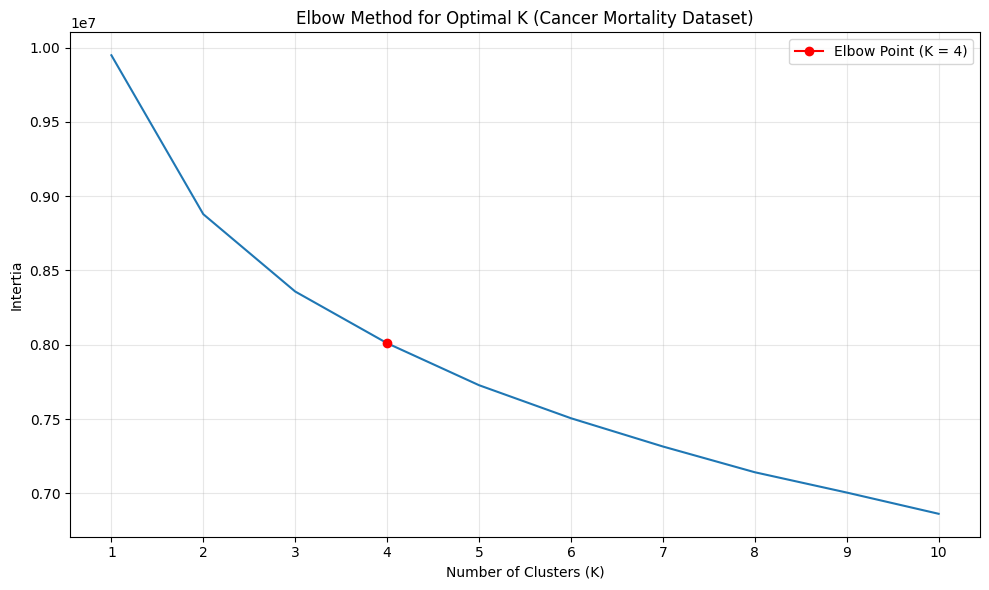

In [11]:
k_range = range(1, 11)
inertias = []

# Compute inertia for each K
for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=random_state, n_init=10)
    kmeans.fit(X_reduced)
    inertias.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(k_range, inertias)
plt.title('Elbow Method for Optimal K (Cancer Mortality Dataset)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Intertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Finding optimal K
knee = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.elbow
optimal_inertia = knee.knee_y

plt.plot(optimal_k, optimal_inertia, marker='o', color='red', label=f"Elbow Point (K = {optimal_k})")

plt.legend()
plt.tight_layout()
plt.show()

In [6]:
df_elbow = cancer_deaths.copy()

# Preserving original years for cluster table later
years_original = df_elbow['DATA_YEAR'].copy()

# Cyclical encoding for MONTH and WEEKDAY
df_elbow['MONTH_SIN'] = np.sin(2 * np.pi * df_elbow['MONTH_OF_DEATH'] / 12)
df_elbow['MONTH_COS'] = np.cos(2 * np.pi * df_elbow['MONTH_OF_DEATH'] / 12)
df_elbow['WEEKDAY_SIN'] = np.sin(2 * np.pi * df_elbow['WEEKDAY_OF_DEATH'] / 7)
df_elbow['WEEKDAY_COS'] = np.cos(2 * np.pi * df_elbow['WEEKDAY_OF_DEATH'] / 7)

# Drop original cols
df_elbow = df_elbow.drop(columns=['MONTH_OF_DEATH', 'WEEKDAY_OF_DEATH', 'DATA_YEAR'])

# Scale continuous AGE target
scaler = StandardScaler()
df_elbow[['AGE']] = scaler.fit_transform(df_elbow[['AGE']])

# PCA to reduce dimensionality (originally 100+ features)
pca = PCA(n_components=0.85) # retaining 85% of variance
X_reduced = pca.fit_transform(df_elbow)

# K-Means
kmeans_elbow = KMeans(n_clusters=4, random_state=random_state)
clusters_elbow = kmeans_elbow.fit_predict(X_reduced)

cluster_year_counts_elbow = pd.crosstab(clusters_elbow, years_original, normalize='columns') * 100
print(cluster_year_counts_elbow)


DATA_YEAR       2018       2019       2020
row_0                                     
0          19.314146  19.588802  19.698216
1          25.144573  25.064725  24.891901
2          30.403360  30.534562  30.428351
3          25.137922  24.811911  24.981533


In [11]:
df_analysis_elbow = cancer_deaths.copy()
df_analysis_elbow['CLUSTER'] = clusters_elbow

# separate continuous vs binary features
continuous_col = ['AGE']
metadata_cols = ['CLUSTER', 'DATA_YEAR', 'MONTH_OF_DEATH', 'WEEKDAY_OF_DEATH']
binary_cols = [c for c in df_analysis_elbow.columns if c not in continuous_col + metadata_cols]

# Group profiles
print("=== AVERAGE AGE BY CLUSTER ===")
display(df_analysis_elbow.groupby('CLUSTER')[['AGE']].mean())

# Full population baseline
overall_means = df_analysis_elbow[binary_cols].mean()


n_characteristics = 10      # top n features for cluster
n_largest_shifts = 5        # top n features with the largest shifts from the population mean

# display cluster characteristics and shifts
for i in range(4):
    cluster_df_elbow = df_analysis_elbow[df_analysis_elbow['CLUSTER'] == i]
    cluster_means_elbow = cluster_df_elbow[binary_cols].mean()

    # top prevalance
    top_prev_elbow = (
        (cluster_means_elbow.sort_values(ascending=False).head(n_characteristics) * 100)
        .round(2)
        .to_frame(name="Prevalance (%)")
    )

    # Top Unique Shifts vs Overall Population
    diff_elbow = (cluster_means_elbow - overall_means) * 100
    top_diff_elbow_idx = diff_elbow.abs().sort_values(ascending=False).head(n_largest_shifts).index
    top_unique_elbow = diff_elbow.loc[top_diff_elbow_idx].to_frame(name='Shift vs Baseline (%)')

    # Render Output
    display(HTML(f"<h3>Cluster {i} Summary</h3>"))

    # Display side-by-side or stacked styled DataFrames with visual gradient bars
    display(
        top_prev_elbow.style.background_gradient(cmap="Greens").format("{:.2f}%")
    )
    display(
        top_unique_elbow.style.background_gradient(cmap="coolwarm", vmin=50, vmax=50).format("{:+.2f}%")
    )
    display(HTML("<hr>")) # Visual separator

=== AVERAGE AGE BY CLUSTER ===


,AGE
CLUSTER,
0,65.155752
1,65.976755
2,85.333077
3,65.982912


,Prevalance (%)
AUTOPSY_N,94.84%
RESIDENT_STATUS_Resident,83.45%
RACE_Black,55.56%
ETHNIC_GROUP_Non-Hispanic Black,55.56%
SEX_Female,47.51%
MARITAL_STATUS_Married,46.92%
PLACE_OF_DEATH_Home,40.97%
EDUCATION_HS Grad / GED,37.64%
PLACE_OF_DEATH_Hospital (Inpatient),32.49%
RACE_Hispanic,29.27%


,Shift vs Baseline (%)
RACE_White,-76.98%
ETHNIC_GROUP_Non-Hispanic White,-76.98%
ETHNIC_GROUP_Non-Hispanic Black,+43.70%
RACE_Black,+43.70%
RACE_Hispanic,+22.14%


,Prevalance (%)
RACE_White,99.96%
ETHNIC_GROUP_Non-Hispanic White,99.96%
AUTOPSY_N,95.73%
RESIDENT_STATUS_Resident,80.03%
MARITAL_STATUS_Married,59.62%
PLACE_OF_DEATH_Home,47.71%
SEX_Female,42.99%
EDUCATION_HS Grad / GED,41.13%
"CAUSE_OF_DEATH_Malignant neoplasms of trachea, bronchus and lung (C33-C34)",29.86%
PLACE_OF_DEATH_Hospital (Inpatient),24.56%


,Shift vs Baseline (%)
RACE_White,+22.99%
ETHNIC_GROUP_Non-Hispanic White,+22.99%
MARITAL_STATUS_Widowed,-15.72%
ETHNIC_GROUP_Non-Hispanic Black,-11.86%
RACE_Black,-11.86%


,Prevalance (%)
AUTOPSY_N,96.67%
RACE_White,88.59%
ETHNIC_GROUP_Non-Hispanic White,88.59%
RESIDENT_STATUS_Resident,87.50%
MARITAL_STATUS_Widowed,55.98%
SEX_Female,54.04%
PLACE_OF_DEATH_Home,48.44%
EDUCATION_HS Grad / GED,44.04%
MARITAL_STATUS_Married,31.11%
"CAUSE_OF_DEATH_Malignant neoplasms of trachea, bronchus and lung (C33-C34)",24.55%


,Shift vs Baseline (%)
MARITAL_STATUS_Widowed,+32.70%
MARITAL_STATUS_Married,-17.33%
RACE_White,+11.62%
ETHNIC_GROUP_Non-Hispanic White,+11.62%
PLACE_OF_DEATH_Hospital (Inpatient),-9.70%


,Prevalance (%)
RACE_White,99.97%
ETHNIC_GROUP_Non-Hispanic White,99.97%
AUTOPSY_N,95.88%
RESIDENT_STATUS_Resident,79.36%
MARITAL_STATUS_Married,59.55%
PLACE_OF_DEATH_Home,46.21%
SEX_Female,43.13%
EDUCATION_HS Grad / GED,41.16%
"CAUSE_OF_DEATH_Malignant neoplasms of trachea, bronchus and lung (C33-C34)",29.75%
PLACE_OF_DEATH_Hospital (Inpatient),25.68%


,Shift vs Baseline (%)
RACE_White,+23.00%
ETHNIC_GROUP_Non-Hispanic White,+23.00%
MARITAL_STATUS_Widowed,-15.84%
ETHNIC_GROUP_Non-Hispanic Black,-11.86%
RACE_Black,-11.86%


## Cluster Summary (K=4):

#### Cluster 0: Racial Minority Population
- **Average Age:** 65.15
- **Core Profile:**
  - 55.56% Black / Non-Hispanic Black
  - 29.27% Hispanic
- **Other Key Characteristics:**
  - 47.51% Female
  - 46.92% Married
  - 40.97% Died at Home
  - 32.49% Died in Hospital (Inpatient)
- **Defining Shifts vs. Baseline:**
  - -76.98% White / Non-Hispanic White
  - +43.70% Black / Non-Hispanic Black
  - +22.14% Hispanic
- **Main Takeaway:** Cluster highlights significant racial/ethnic disparities in cancer mortalities dying roughly 0.8 years earlier compared to predominantly White clusters 1 and 3. This cluster also faces the highest hospital inpatient deaths with 32.49% (roughly 7% higher than the second highest group, Cluster 3, which is virtually all White). This might signal to potential barriers in early detection.

#### Cluster 1: Married White Population with High Lung Cancer Rates
- **Average Age:** 65.97
- **Core Profile:**
  - 99.96% White / Non-Hispanic White
- **Other Key Characteristics:**
  - 42.99% Female
  - 59.62% Married
  - 47.71% Died at Home
  - 24.56% Died in Hospital (Inpatient)
  - 29.86% Died from malignant neoplasms of trachea, bronchus and lung
- **Defining Shifts vs. Baseline:**
  - +22.99% White / Non-Hispanic White
  - -15.72% Widowed
  - -11.86% Black / Non-Hispanic Black
- **Main Takeaway:** Cluster is nearly exclusively White with high lung cancer deaths. However, they have the second highest rate of dying at home. This group also has the highest marriage rates, indicating the potential for more spousal caregiving capacity at home that enable families to choose home hospice over extended hospital stays or nursing homes.

#### Cluster 2: Older Widowed Female Majority Population
- **Average Age:** 85.33
- **Core Profile:**
  - 88.59% White / Non-Hispanic White
- **Other Key Characteristics:**
  - 54.04% Female
  - 31.11% Married
  - 55.98% Widowed
  - 48.44% Died at Home
  - 24.55% Died from malignant neoplasms of trachea, bronchus and lung
- **Defining Shifts vs. Baseline:**
  - +32.70% Widowed
  - -17.33% Married
  - +11.62% White / Non-Hispanic White
  - -9.70% Died in Hosptial (Inpatient)
- **Main Takeaway:** Cluster represents the oldest demographic in the dataset and second most diverse cluster. This group on average dies roughly 20 years later than the other clusters. This potentially represents women living alone with reduced household caregiving infrastructure leading to higher reliance on institutional settings such as nursing homes. They also die significantly higher from lung cancers than most clusters.

#### Cluster 3: Married White Population with High Lung Cancer Rates (V2)
- **Average Age:** 65.98
- **Core Profile:**
  - 99.97% White / Non-Hispanic White
- **Other Key Characteristics:**
  - 43.13% Female
  - 59.55% Married
  - 46.21% Died at Home
  - 25.68% Died in Hospital (Inpatient)
  - 29.75% Died from malignant neoplasms of trachea, bronchus and lung
- **Defining Shifts vs. Baseline:**
  - +23.00% White / Non-Hispanic White
  - -15.84% Widowed
  - -11.86% Black / Non-Hispanic Black
- **Main Takeaway:** Cluster is virtually identical to Cluster 1. This essentially shows that the dominant characteristics in this dataset are married White men with potentially more spousal caregiving capacity at home that enable families to choose home hospice over extended hospital stays or nursing homes.